# **Analisis Sentiment dengan Super Vector Machine (SVM) menggunakan dataset dari IndoNLU**

# 0.Import Library

In [1]:
import pandas as pd
 
%matplotlib inline
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn import svm
from sklearn.metrics import classification_report

In [2]:
!git clone https://github.com/indobenchmark/indonlu

fatal: destination path 'indonlu' already exists and is not an empty directory.


In [3]:
df_tr = pd.read_csv('indonlu/dataset/smsa_doc-sentiment-prosa/train_preprocess.tsv', sep='\t', names=["Teks", "Target"])
df_tr.head()

,Teks,Target
0,warung ini dimiliki oleh pengusaha pabrik tahu...,positive
1,mohon ulama lurus dan k212 mmbri hujjah partai...,neutral
2,lokasi strategis di jalan sumatera bandung . t...,positive
3,betapa bahagia nya diri ini saat unboxing pake...,positive
4,duh . jadi mahasiswa jangan sombong dong . kas...,negative


In [4]:
df_te = pd.read_csv('indonlu/dataset/smsa_doc-sentiment-prosa/valid_preprocess.tsv', sep='\t', names=["Teks", "Target"])
df_te

,Teks,Target
0,"meski masa kampanye sudah selesai , bukan bera...",neutral
1,tidak enak,negative
2,restoran ini menawarkan makanan sunda . kami m...,positive
3,lokasi di alun alun masakan padang ini cukup t...,positive
4,betapa bejad kader gerindra yang anggota dprd ...,negative
...,...,...
1255,"film tncfu , tidak cocok untuk penonton yang t...",negative
1256,"indihome ini mahal loh bayar nya . hanya , pen...",negative
1257,"be de gea , cowok cupu yang takut dengan pacar...",negative
1258,valen yang sangat tidak berkualitas . konentat...,negative


# 2.Exploratory Data Analysis

In [5]:
print('Data Train: {}, Data Test: {}'.format(df_tr.shape, df_te.shape))

Data Train: (11000, 2), Data Test: (1260, 2)


In [6]:
# Menghitung jumlah data masing-masing variabel pada kolom Target
df_tr['Target'].value_counts()

Target
positive    6416
negative    3436
neutral     1148
Name: count, dtype: int64

<Axes: xlabel='Target'>

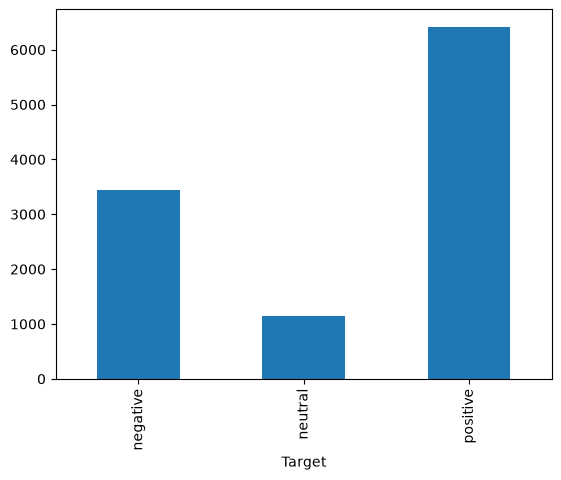

In [7]:
df_tr.groupby(['Target']).size().plot(kind='bar')

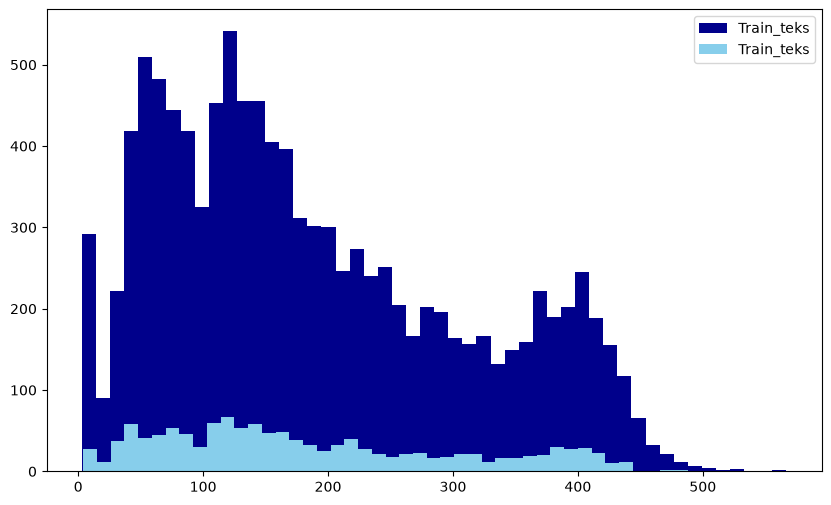

In [8]:
# Melihat panjang teks dalam data train dan test

len_tr = df_tr['Teks'].str.len()
len_te = df_te['Teks'].str.len()

plt.figure(figsize=(10, 6))
plt.hist(len_tr, bins=50, label='Train_teks', color='darkblue')
plt.hist(len_te, bins=50, label='Train_teks', color='skyblue')
plt.legend()

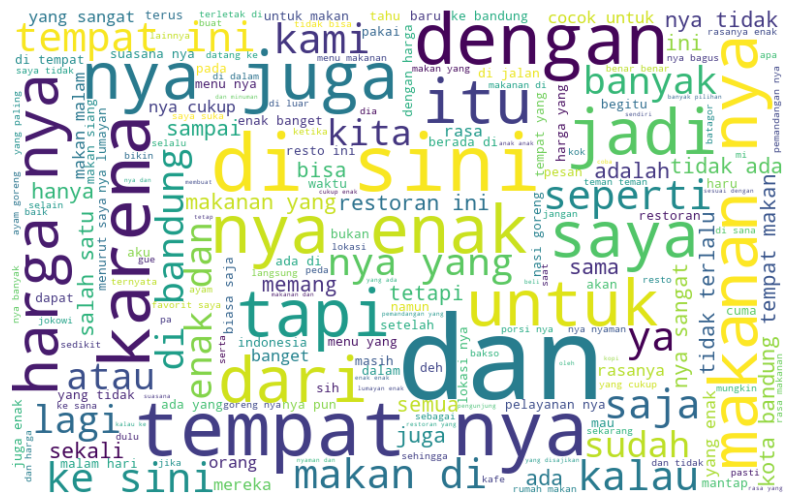

In [9]:
# Sentimen yang ada pada seluruh data train dapat dilihat dengan memahami kata yang umum dengan plot word cloud

def wordCloud(words):
    wordCloud = WordCloud(width=800, height=500, background_color='white', random_state=21, max_font_size=120).generate(words)

    plt.figure(figsize=(10, 7))
    plt.imshow(wordCloud, interpolation='bilinear')
    plt.axis('off')

all_words = ' '.join([text for text in df_tr['Teks']])
wordCloud(all_words)

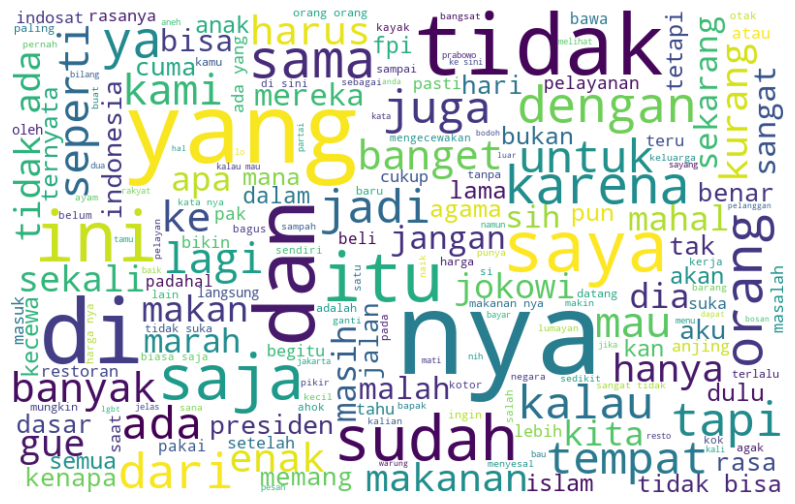

In [10]:
# Melihat kata-kata yang negatif
negative_words = ' '.join(text for text in df_te['Teks'][df_te['Target'] == 'negative']) 
wordCloud(negative_words)

# 3.Feature Engineering

In [11]:
# Word Embedding menggunkana TF-IDF

tfidfvec = TfidfVectorizer(
    # min_df: Digunakan untuk menghilangkan term/istilah yang terlalu jarang muncul.
    # Sebagai contoh, jika diset min_df = 0.01, artinya kita mengabaikan term yang muncul kurang dari 1% dalam teks.
    # Jika diset min_df = 5,
    # artinya kita mengabaikan term yang muncul dalam kurang dari 5 dokumen.
    min_df=5,

    # max_df: Digunakan untuk menghilangkan term yang terlalu sering muncul,
    # biasanya merupakan stop words.
    # Sebagai contoh, jika diset max_df=0.8, artinya kita mengabaikan term yang muncul lebih dari 80% dalam teks.
    # Jika diset 25, artinya kita mengabaikan term yang muncul di lebih dari 25 dokumen.
    max_df=0.8,

    # sublinear_tf: Berfungsi untuk melakukan scaling dan bernilai boolean dengan default false. 
    # Sublinear_tf=True akan mengubah vektor frekuensi menjadi bentuk logaritmik (1+log(tf)). 
    # Sehingga dapat menormalisasi bias terhadap teks yang panjang dan teks yang pendek.
    sublinear_tf=True,

    # use_idf: Bernilai boolean dengan default True. 
    # Parameter ini memungkinkan kita untuk menggunakan Inverse Document Frequency (IDF). 
    # Hal ini berarti term yang terlalu sering muncul dalam teks akan diberi skor lebih sedikit dibanding term yang jarang muncul (hanya muncul pada teks yang spesifik saja).
    use_idf=True
)

In [12]:
tr_vec = tfidfvec.fit_transform(df_tr['Teks'])

In [13]:
te_vec = tfidfvec.transform(df_te['Teks'])

In [14]:
# melakukan klasifikasi dengan SVM, kernel=linear
classifier_linear = svm.SVC(kernel='linear')
classifier_linear.fit(tr_vec, df_tr['Target'])
prediction_linear = classifier_linear.predict(tr_vec)

In [15]:
# print metriks
target_names = ['positive', 'negative', 'netral']
print(classification_report(df_tr['Target'], prediction_linear, target_names=target_names))

              precision    recall  f1-score   support

    positive       0.91      0.91      0.91      3436
    negative       0.94      0.91      0.92      1148
      netral       0.95      0.95      0.95      6416

    accuracy                           0.94     11000
   macro avg       0.93      0.92      0.93     11000
weighted avg       0.94      0.94      0.94     11000



In [16]:
teks = 'Bahagia hatiku melihat pernikahan putri sulungku yang cantik jelita'
teks_vector = tfidfvec.transform([teks]) # vectorizing
print(classifier_linear.predict(teks_vector))

['positive']


In [17]:
def pred_classification_svm(text):
    teks_vector = tfidfvec.transform([teks])  # vectorizing
    print(classifier_linear.predict(teks_vector)[0])

In [18]:
texts = [
    'Ronaldo pergi ke Mall Grand Indonesia membeli cilok',
    'Sayang, aku marah',
    'Merasa kagum dengan toko ini tapi berubah menjadi kecewa setelah transaksi'
]

[pred_classification_svm(text) for text in texts]

positive
positive
positive


[None, None, None]